<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_0_Preliminaries/17_0_5_Rsquared.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression Preliminaries: RSS and $R^2$

Author: Brad Sheese

---



## What This Notebook Is About

This is the last notebook in the preliminaries. Everything we've built so far comes together here:

- **Notebook 1** — baseline model (the mean), and how to measure *its* total error: the **Total Sum of Squares (TSS)**.
- **Notebook 2** — always look at the data before modeling it.
- **Notebook 3** — **Pearson's correlation** $r$: a unitless, standardized measure of how tightly two variables move together.
- **Notebook 4** — the **residual** $e_i = y_i - \hat{y}_i$: the vertical distance from an actual data point to the prediction line. We also learned that summing residuals doesn't work because positive and negative errors cancel.

In this notebook we fix the cancellation problem exactly the same way we fixed it in Notebook 1, by squaring, and that single move gives us three things:

1. **RSS**, a proper score for how wrong a line is.
2. **A U-shaped error landscape** with one mathematically optimal slope at the bottom.
3. **$R^2$**, the universal score for regression models, defined directly in terms of RSS and TSS.

And by the end, we'll discover that we don't actually need a computer to search for the best line at all. There's a closed-form formula for the optimal slope, and it's built entirely out of quantities we already know: $r$, $\sigma_x$, and $\sigma_y$. That formula *is* Simple Linear Regression.

## Setup

We'll use the **Ames Housing** dataset. It has prices on 2,930 homes sold in Ames, Iowa in the early 2000's.

Our $x$ will be `area`, the above-ground living area in square feet.

Our $y$ will be `price`, the sale price, which we'll divide by 1,000 so we're working in *thousands of dollars* (so a 250,000 dollar home shows up as 250.0). This just makes numbers on the plots easier to read; it doesn't affect the slopes of anything we care about.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import io
import urllib.request

sns.set_style('whitegrid')

# Load Ames Housing from OpenIntro. OpenIntro's server requires a real-looking
# User-Agent header, so we fetch the bytes via urllib and parse with pandas.
url = 'https://www.openintro.org/data/csv/ames.csv'
req = urllib.request.Request(
    url,
    headers={
        'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36',
        'Accept': 'text/csv,*/*',
    },
)
with urllib.request.urlopen(req) as resp:
    ames = pd.read_csv(io.BytesIO(resp.read()))

x = ames['area'].to_numpy()               # above-ground living area (sq ft)
y = ames['price'].to_numpy() / 1000.0     # sale price in thousands of dollars

print(f'Homes: {len(x)}')
print(f'Median area: {np.median(x):.0f} sq ft')
print(f'Median price: ${np.median(y):.1f}K')

Homes: 2930
Median area: 1442 sq ft
Median price: $160.0K


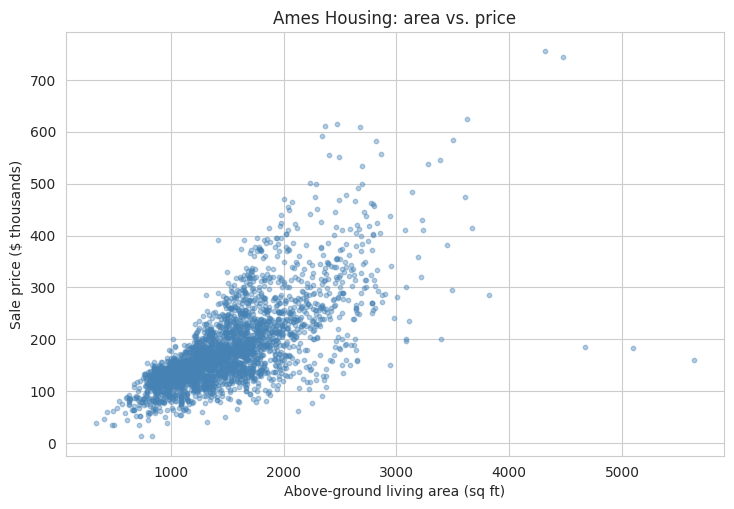

In [ ]:
# Rule from Notebook 2: always look at the data.
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(x, y, s=10, alpha=0.4, color='steelblue')
ax.set_xlabel('Above-ground living area (sq ft)')
ax.set_ylabel('Sale price ($ thousands)')
ax.set_title('Ames Housing: area vs. price')
plt.show()

---

## Section 1: Residual Sum of Squares (RSS)

### The fix we already know

In Notebook 4 we saw that summing residuals is useless: a terrible line can score zero because positive and negative residuals cancel. That same cancellation problem happened in Notebook 1 when we tried to sum deviations from the mean, and we fixed it there by **squaring** each deviation before summing.

We'll do the exact same thing here. Define the **Residual Sum of Squares**:

$$\text{RSS} = \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

Every squared residual is non-negative, so RSS can't be gamed by cancellation. A line with RSS = 0 fits every point exactly. A line with huge RSS is a bad fit. We call this an **objective function**,  which is a single number we want the line to minimize. The whole game of regression is finding the line with the smallest possible RSS.

### A helpful simplification for our search

A line needs two parameters: slope $m$ and intercept $b$. Searching a whole 2D plane of $(m, b)$ pairs would take a 3D surface plot, which is harder to draw on a notebook page. Let's collapse the problem down to 1D.

In Notebook 4 we stumbled on a neat fact: any line that passes through the point $(\bar{x}, \bar{y})$ has residuals that sum to zero. This "passes-through-the-centroid" family of lines contains the optimal regression line (you'll just have to take my word for this right now. We'll see why at the end of the notebook). So we can restrict our search to that family without losing the best line.

Every line that passes through $(\bar{x}, \bar{y})$ can be written as:

$$\hat{y} = m\,(x - \bar{x}) + \bar{y}$$

So the **only thing left to pick is the slope $m$**. Let's have the computer try 100 different slopes, compute RSS for each, and plot the result.

In [ ]:
x_mean = np.mean(x)
y_mean = np.mean(y)

# 100 candidate slopes, from gentle to steep.
candidate_slopes = np.linspace(0.01, 0.20, 100)

rss_scores = []
for m in candidate_slopes:
    # Line passing through (x_mean, y_mean) with slope m
    y_hat = m * (x - x_mean) + y_mean
    residuals = y - y_hat
    rss = np.sum(residuals ** 2)
    rss_scores.append(rss)

rss_scores = np.array(rss_scores)
best_index = np.argmin(rss_scores)
print(f'Best slope in our sweep: m = {candidate_slopes[best_index]:.4f}')
print(f'Lowest RSS in our sweep:   {rss_scores[best_index]:,.0f}')

Best slope in our sweep: m = 0.1117
Lowest RSS in our sweep:   9,354,908


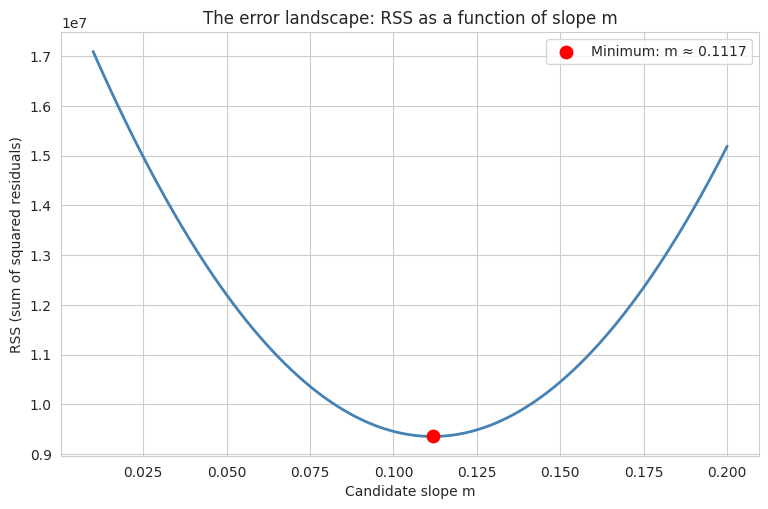

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(candidate_slopes, rss_scores, color='steelblue', linewidth=2)
ax.scatter([candidate_slopes[best_index]], [rss_scores[best_index]],
           color='red', s=80, zorder=5,
           label=f'Minimum: m \u2248 {candidate_slopes[best_index]:.4f}')
ax.set_xlabel('Candidate slope m')
ax.set_ylabel('RSS (sum of squared residuals)')
ax.set_title('The error landscape: RSS as a function of slope m')
ax.legend()
plt.show()

### The U-shaped bowl

Every candidate slope gives a line; every line produces an RSS; plotting RSS against slope gives a **smooth, perfectly convex U-shape**. This shape shows up constantly in machine learning. It's one of the most important pictures in the entire field. It tells us:

- There is **exactly one best slope**. No ambiguity.
- On either side of the best slope, RSS rises. Lines that are too shallow miss the trend; lines that are too steep overshoot it. Both are punished.
- The "bottom of the bowl" is where our residuals are smallest *in total*. That bottom is our line of best fit.

What you just did has a fancy name: **Ordinary Least Squares (OLS)** regression. We searched a parameter space for the setting that minimizes squared error. We did it with a slow brute-force loop, but the idea is exactly the same idea that drives $\texttt{LinearRegression().fit()}$ in scikit-learn.

Let's look at what the best line actually *looks like* on top of the data.

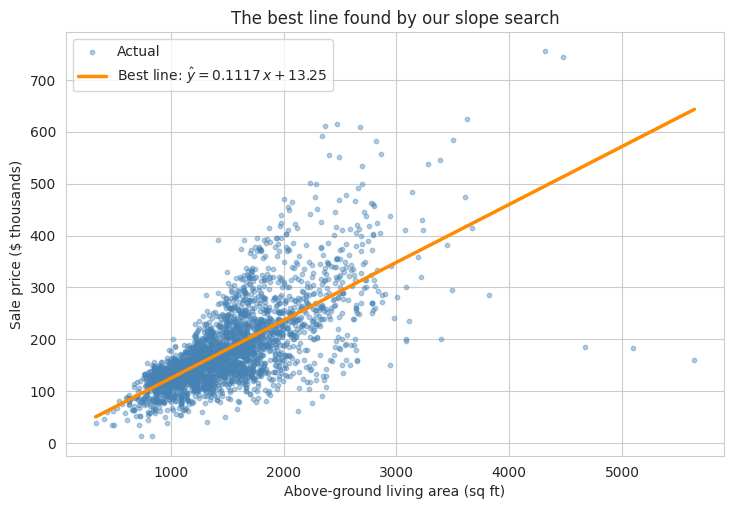

In [ ]:
best_m = candidate_slopes[best_index]
best_b = y_mean - best_m * x_mean   # line passes through (x_mean, y_mean)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(x, y, s=10, alpha=0.4, color='steelblue', label='Actual')
x_grid = np.linspace(x.min(), x.max(), 100)
ax.plot(x_grid, best_m * x_grid + best_b, color='darkorange', linewidth=2.5,
        label=fr'Best line: $\hat{{y}} = {best_m:.4f}\,x + {best_b:.2f}$')
ax.set_xlabel('Above-ground living area (sq ft)')
ax.set_ylabel('Sale price ($ thousands)')
ax.set_title('The best line found by our slope search')
ax.legend()
plt.show()

---

## Section 2: The True Meaning of $R^2$

Our best line has the smallest possible RSS. We computed that number: about **9.35 million**. In units of *squared thousands of dollars*.

**Is 9.35 million a good RSS?** We have no idea. That number, on its own, is meaningless. It is:

- In weird units, squared thousands of dollars. This is the same problem we had with variance.
- Totally dependent on the scale and size of the dataset. A dataset with 30,000,000 homes would have a much larger RSS even if the line fit just as well.

To decide if RSS = 9.35M is good, we need **something to compare it to**. And we have something perfect sitting there from Notebook 1. That is the error of the baseline model which ignores square footage entirely and just guesses the mean every time.

In [ ]:
# TSS -- from Notebook 1.
tss = np.sum((y - y_mean) ** 2)
rss_best = rss_scores[best_index]

print(f'TSS  (baseline model = always guess the mean): {tss:>18,.0f}')
print(f'RSS  (our best line):                          {rss_best:>18,.0f}')

TSS  (baseline model = always guess the mean):         18,692,537
RSS  (our best line):                                   9,354,908


### Reading the comparison

- **TSS ≈ 18.7 million.** This is the total squared error you'd incur if you knew nothing about a house other than it's a house in Ames, Iowa, and you guessed the mean price every time. It's the error of the baseline model.
- **RSS ≈ 9.35 million.** This is the total squared error you incur if you *do* look at square footage and draw our best line through the data. It's the error of our model.

Our model's error is about half of the baseline's error. Our line cut the baseline's error roughly in half by using a single piece of information (square footage). **That's the real accomplishment, and it's the thing we want to measure.**

### The formula

We want a score that says "what fraction of the baseline's error did we eliminate?" That's:

$$R^2 = 1 - \frac{\text{RSS}}{\text{TSS}}$$

That is the true definition of **R-squared**.

In [ ]:
r_squared = 1 - rss_best / tss
print(f'R^2 = 1 - RSS/TSS = 1 - {rss_best:,.0f} / {tss:,.0f}')
print(f'R^2 = {r_squared:.4f}')

R^2 = 1 - RSS/TSS = 1 - 9,354,908 / 18,692,537
R^2 = 0.4995


### How to read $R^2$

Plain-English translation: **our model explained away about 50% of the baseline's error.** By using square footage to predict price, we cut the errors we would have made by guessing the mean roughly in half.

A few reference points:

| $R^2$ | Meaning |
|---|---|
| $1.00$ | RSS = 0. The line fits every point exactly. (Almost never happens on real data.) |
| $0.50$ | Our line cut the baseline's error in half. |
| $0.00$ | RSS = TSS. The line is no better than guessing the mean. The model is useless. |
| $< 0$  | *Worse* than guessing the mean. (Yes, possible, usually when you do something strange.) |

This interpretation, *"the fraction of the baseline's squared error that the model explains"*, is the real, universal definition of $R^2$. It works for simple linear regression. It works for multiple linear regression. It works for polynomial regression and other fancier models. It is the single most important scoring metric in regression.

---

## Section 3: The Shortcut — Simple Linear Regression in One Line

### Do we really need that `for` loop?

In Section 1 we found the best slope by brute force: try 100 candidate slopes and pick the smallest RSS. That worked, but:

- It's slow.
- It's only approximate. The best slope is somewhere *near* whichever of our 100 points had the lowest RSS, but not exactly at it.
- What if we needed to search over thousands of dimensions (as we'll do with Multiple Linear Regression later)? Brute-forcing a parameter space is not a scalable strategy.

It turns out mathematicians solved this problem exactly, centuries ago, using calculus. There is a **closed-form formula** that gives you the exact slope at the bottom of the bowl. No searching required. And here's the satisfying part: the formula is built entirely out of pieces you already know.

### The formula

The slope that minimizes RSS in simple linear regression is:

$$m = r \cdot \frac{\sigma_y}{\sigma_x}$$

And the intercept that goes with it is:

$$b = \bar{y} - m\,\bar{x}$$

Pause on this for a moment. Everything on the right-hand side is something we've already computed in these preliminaries:

- $r$ — Pearson's correlation coefficient (Notebook 3)
- $\sigma_x, \sigma_y$ — standard deviations (Notebook 1)
- $\bar{x}, \bar{y}$ — the means (Notebook 1)

**Simple linear regression is just correlation, rescaled by how spread out $y$ is relative to $x$.** That's it. That's the whole trick.

In [ ]:
# All pieces from earlier notebooks:
r_corr = np.corrcoef(x, y)[0, 1]
sigma_x = np.std(x)
sigma_y = np.std(y)

# The OLS cheat code:
m_optimal = r_corr * (sigma_y / sigma_x)
b_optimal = y_mean - m_optimal * x_mean

print(f'r           = {r_corr:.4f}')
print(f'sigma_x     = {sigma_x:.4f}')
print(f'sigma_y     = {sigma_y:.4f}')
print(f'Optimal m   = r * (sigma_y / sigma_x) = {m_optimal:.6f}')
print(f'Optimal b   = y_mean - m * x_mean     = {b_optimal:.4f}')

r           = 0.7068
sigma_x     = 505.4226
sigma_y     = 79.8731
Optimal m   = r * (sigma_y / sigma_x) = 0.111694
Optimal b   = y_mean - m * x_mean     = 13.2896


### Does the formula really hit the bottom of the bowl?

We found a slope with the `for` loop. We now have a slope from the formula. Let's overlay the formula's slope on the bowl and see how close the formula landed to the true minimum.

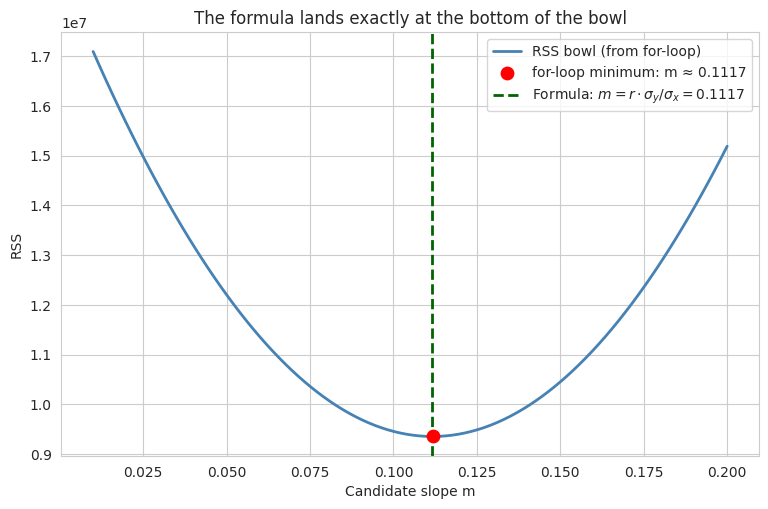

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(candidate_slopes, rss_scores, color='steelblue', linewidth=2,
        label='RSS bowl (from for-loop)')
ax.scatter([candidate_slopes[best_index]], [rss_scores[best_index]],
           color='red', s=80, zorder=5,
           label=f'for-loop minimum: m \u2248 {candidate_slopes[best_index]:.4f}')
ax.axvline(m_optimal, color='darkgreen', linestyle='--', linewidth=2,
           label=fr'Formula: $m = r \cdot \sigma_y/\sigma_x = {m_optimal:.4f}$')
ax.set_xlabel('Candidate slope m')
ax.set_ylabel('RSS')
ax.set_title('The formula lands exactly at the bottom of the bowl')
ax.legend()
plt.show()

The green dashed line drops down *precisely* onto the bottom of the bowl. It's not magic. It's the exact value that calculus says makes the derivative of RSS with respect to slope equal to zero. We didn't search for it; we *computed* it in constant time from quantities we already had.

> **This is what simple linear regression is.** Pick the slope $m = r \cdot \sigma_y/\sigma_x$ and the intercept $b = \bar{y} - m\bar{x}$. Done. That line is guaranteed to minimize the sum of squared residuals, and its $R^2$ is your score.

### A beautiful bonus: for simple linear regression, $R^2 = r^2$

Let's verify one more thing. We defined two seemingly different scores in these preliminaries:

- **$r$**: Pearson's correlation coefficient, the standardized measure of how tightly two variables co-vary (Notebook 3).
- **$R^2$**: the fraction of baseline error that our regression line explains away (this notebook).

They came from totally different places. But for simple linear regression they satisfy a surprising identity: $R^2 = r^2$.

In [ ]:
# Compute R^2 at the true optimal line
y_hat_optimal = m_optimal * x + b_optimal
rss_optimal = np.sum((y - y_hat_optimal) ** 2)
r_squared_optimal = 1 - rss_optimal / tss

print(f"Pearson's r:        {r_corr:.6f}")
print(f"Pearson's r^2:      {r_corr ** 2:.6f}")
print(f"Regression R^2:     {r_squared_optimal:.6f}")

Pearson's r:        0.706780
Pearson's r^2:      0.499538
Regression R^2:     0.499538


Identical, to every digit of precision. That is why $R^2$ is read "R-squared". The letter comes from Pearson's $r$. The two concepts are different ideas that happen to produce the same number in the simple linear regression setting.

(This equality does *not* hold for multiple linear regression with more than one predictor. $R^2$ still means "fraction of TSS explained," but there's no single $r$ to square anymore. Keep the right mental model: $R^2$ is defined by RSS and TSS. That definition is the one that always works.)

---

## Putting It All Together

Here are the concepts of the entire preliminaries series, in one place:

| Notebook | Concept | Formula |
|---|---|---|
| 1 | Mean | $\bar{y} = \frac{1}{N}\sum y_i$ |
| 1 | Total Sum of Squares | $\text{TSS} = \sum (y_i - \bar{y})^2$ |
| 1 | Variance / Std. dev. | $\sigma_y^2 = \text{TSS}/N$, $\sigma_y = \sqrt{\sigma_y^2}$ |
| 3 | Covariance | $\text{Cov}(x,y) = \frac{1}{N}\sum (x_i - \bar{x})(y_i - \bar{y})$ |
| 3 | Correlation | $r = \text{Cov}(x,y) / (\sigma_x \sigma_y)$ |
| 4 | Residual | $e_i = y_i - \hat{y}_i$ |
| 5 | Residual Sum of Squares | $\text{RSS} = \sum (y_i - \hat{y}_i)^2$ |
| 5 | $R^2$ | $R^2 = 1 - \text{RSS}/\text{TSS}$ |
| 5 | Optimal slope (SLR) | $m = r \cdot \sigma_y/\sigma_x$ |
| 5 | Optimal intercept (SLR) | $b = \bar{y} - m\bar{x}$ |

The whole arc of these five notebooks is a single story:

> **Start with a naive baseline (guess the mean). Measure its total squared error (TSS). Build a better model using a second variable and a line. Measure *that* model's total squared error (RSS). The fraction of TSS you eliminated is $R^2$.**

Every regression metric, every regression algorithm, every "train/test" plot you'll see in the rest of this course. They are all variations on this theme.

### Where We Go From Here

You now understand, at the level of the math, not just the syntax, what the regression code in the next notebooks is doing.

- When you call `model.fit(X, y)` in scikit-learn, it is finding the bottom of an RSS bowl.
- When you call `model.score(X, y)`, it is computing $1 - \text{RSS}/\text{TSS}$.
- When you read about "loss functions" or "objective functions" in any ML text, the paradigm is the one we just built.

In `17.1_SLR` we'll hand the manual algebra over to scikit-learn and start doing this at scale. Welcome to regression.